# Transformer Model Analysis (DistilBERT)

This notebook analyzes the Transformer model (DistilBERT) trained on our topic classification dataset. We compare its performance against previous methods (N-grams, Word2Vec, and LSTM) and explore what pre-trained contextual embeddings and self-attention bring to the task.

## 0: Init

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings

# suppress warnings
warnings.filterwarnings('ignore')

# add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

from transformer_model import TransformerClassifier
from data_splitting import load_splits

# set style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Setup complete!")

✅ Setup complete!


In [2]:
# load data
data_dir = project_root / 'data' / 'processed'
train_df, val_df, test_df = load_splits(str(data_dir))

print(f"Dataset sizes:")
print(f"  Train:      {len(train_df):,}")
print(f"  Validation: {len(val_df):,}")
print(f"  Test:       {len(test_df):,}")

# for transformer, we use raw text (no preprocessing)
val_texts = val_df['content'].tolist()
val_labels = val_df['unified_topic'].values

# class names
class_names = sorted(train_df['unified_topic'].unique())
print(f"\nClasses: {', '.join(class_names)}")

✅ Loaded train split: 56,111 samples
✅ Loaded validation split: 12,024 samples
✅ Loaded test split: 12,024 samples
Dataset sizes:
  Train:      56,111
  Validation: 12,024
  Test:       12,024

Classes: Business, Entertainment, Health, Politics, Science, Sports, Technology


In [ ]:
# load model
model_path = project_root / 'models' / 'transformer.pkl'
model = TransformerClassifier.load(str(model_path))

print(f"Model configuration:")
print(f"  Base Model: {model.model_name}")
print(f"  Max Length: {model.max_length}")
print(f"  Learning Rate: {model.learning_rate}")
print(f"  Warmup Steps: {model.warmup_steps}")
print(f"  Device: {model.device}")

## 1: Performance Metrics

In [4]:
# load metrics
results_dir = project_root / 'results' / 'transformer'
metrics_file = results_dir / 'transformer_metrics.json'

with open(metrics_file, 'r') as f:
    metrics = json.load(f)

print("Overall Performance:")
print(f"  Accuracy:        {metrics['accuracy']:.4f}")
print(f"  Macro Precision: {metrics['macro_precision']:.4f}")
print(f"  Macro Recall:    {metrics['macro_recall']:.4f}")
print(f"  Macro F1:        {metrics['macro_f1']:.4f}")
print(f"  Training Time:   {metrics.get('training_time_seconds', 0):.2f}s")

Overall Performance:
  Accuracy:        0.9153
  Macro Precision: 0.9141
  Macro Recall:    0.9135
  Macro F1:        0.9137
  Training Time:   32139.74s


In [5]:
# per-class performance
per_class = pd.DataFrame(metrics['per_class_metrics']).T
per_class = per_class.sort_values('f1', ascending=False)

print("\nPer-Class F1 Scores:")
for topic, row in per_class.iterrows():
    print(f"  {topic:15s}: {row['f1']:.3f}")


Per-Class F1 Scores:
  Sports         : 0.985
  Entertainment  : 0.938
  Politics       : 0.927
  Business       : 0.900
  Health         : 0.895
  Technology     : 0.877
  Science        : 0.874


In [6]:
# comparison with previous methods
ngrams_metrics_file = project_root / 'results' / 'ngrams' / 'ngrams_logistic_metrics.json'
embeddings_metrics_file = project_root / 'results' / 'embeddings' / 'embeddings_word2vec_logistic_metrics.json'
lstm_metrics_file = project_root / 'results' / 'lstm' / 'lstm_metrics.json'

comparison_data = {'Transformer': metrics}

if ngrams_metrics_file.exists():
    with open(ngrams_metrics_file, 'r') as f:
        comparison_data['N-grams'] = json.load(f)

if embeddings_metrics_file.exists():
    with open(embeddings_metrics_file, 'r') as f:
        comparison_data['Word2Vec'] = json.load(f)

if lstm_metrics_file.exists():
    with open(lstm_metrics_file, 'r') as f:
        comparison_data['LSTM'] = json.load(f)

if len(comparison_data) > 1:
    comparison = pd.DataFrame({
        method: {
            'Accuracy': data['accuracy'],
            'Macro F1': data['macro_f1'],
            'Training Time (s)': data.get('training_time_seconds', 0)
        }
        for method, data in comparison_data.items()
    })

    print("\n" + "="*60)
    print("METHOD COMPARISON: N-grams vs Word2Vec vs LSTM vs Transformer")
    print("="*60)
    print(comparison.to_string())
    
    best_method = comparison.loc['Macro F1'].idxmax()
    best_f1 = comparison.loc['Macro F1'].max()
    print(f"\n🏆 Best method: {best_method}")
    print(f"   Macro F1: {best_f1:.4f}")


METHOD COMPARISON: N-grams vs Word2Vec vs LSTM vs Transformer
                    Transformer    N-grams  Word2Vec          LSTM
Accuracy               0.915253   0.864105  0.488523      0.856953
Macro F1               0.913738   0.863608  0.483140      0.856106
Training Time (s)  32139.735886  42.560654  7.477609  22812.142639

🏆 Best method: Transformer
   Macro F1: 0.9137


## 2: Visualizations

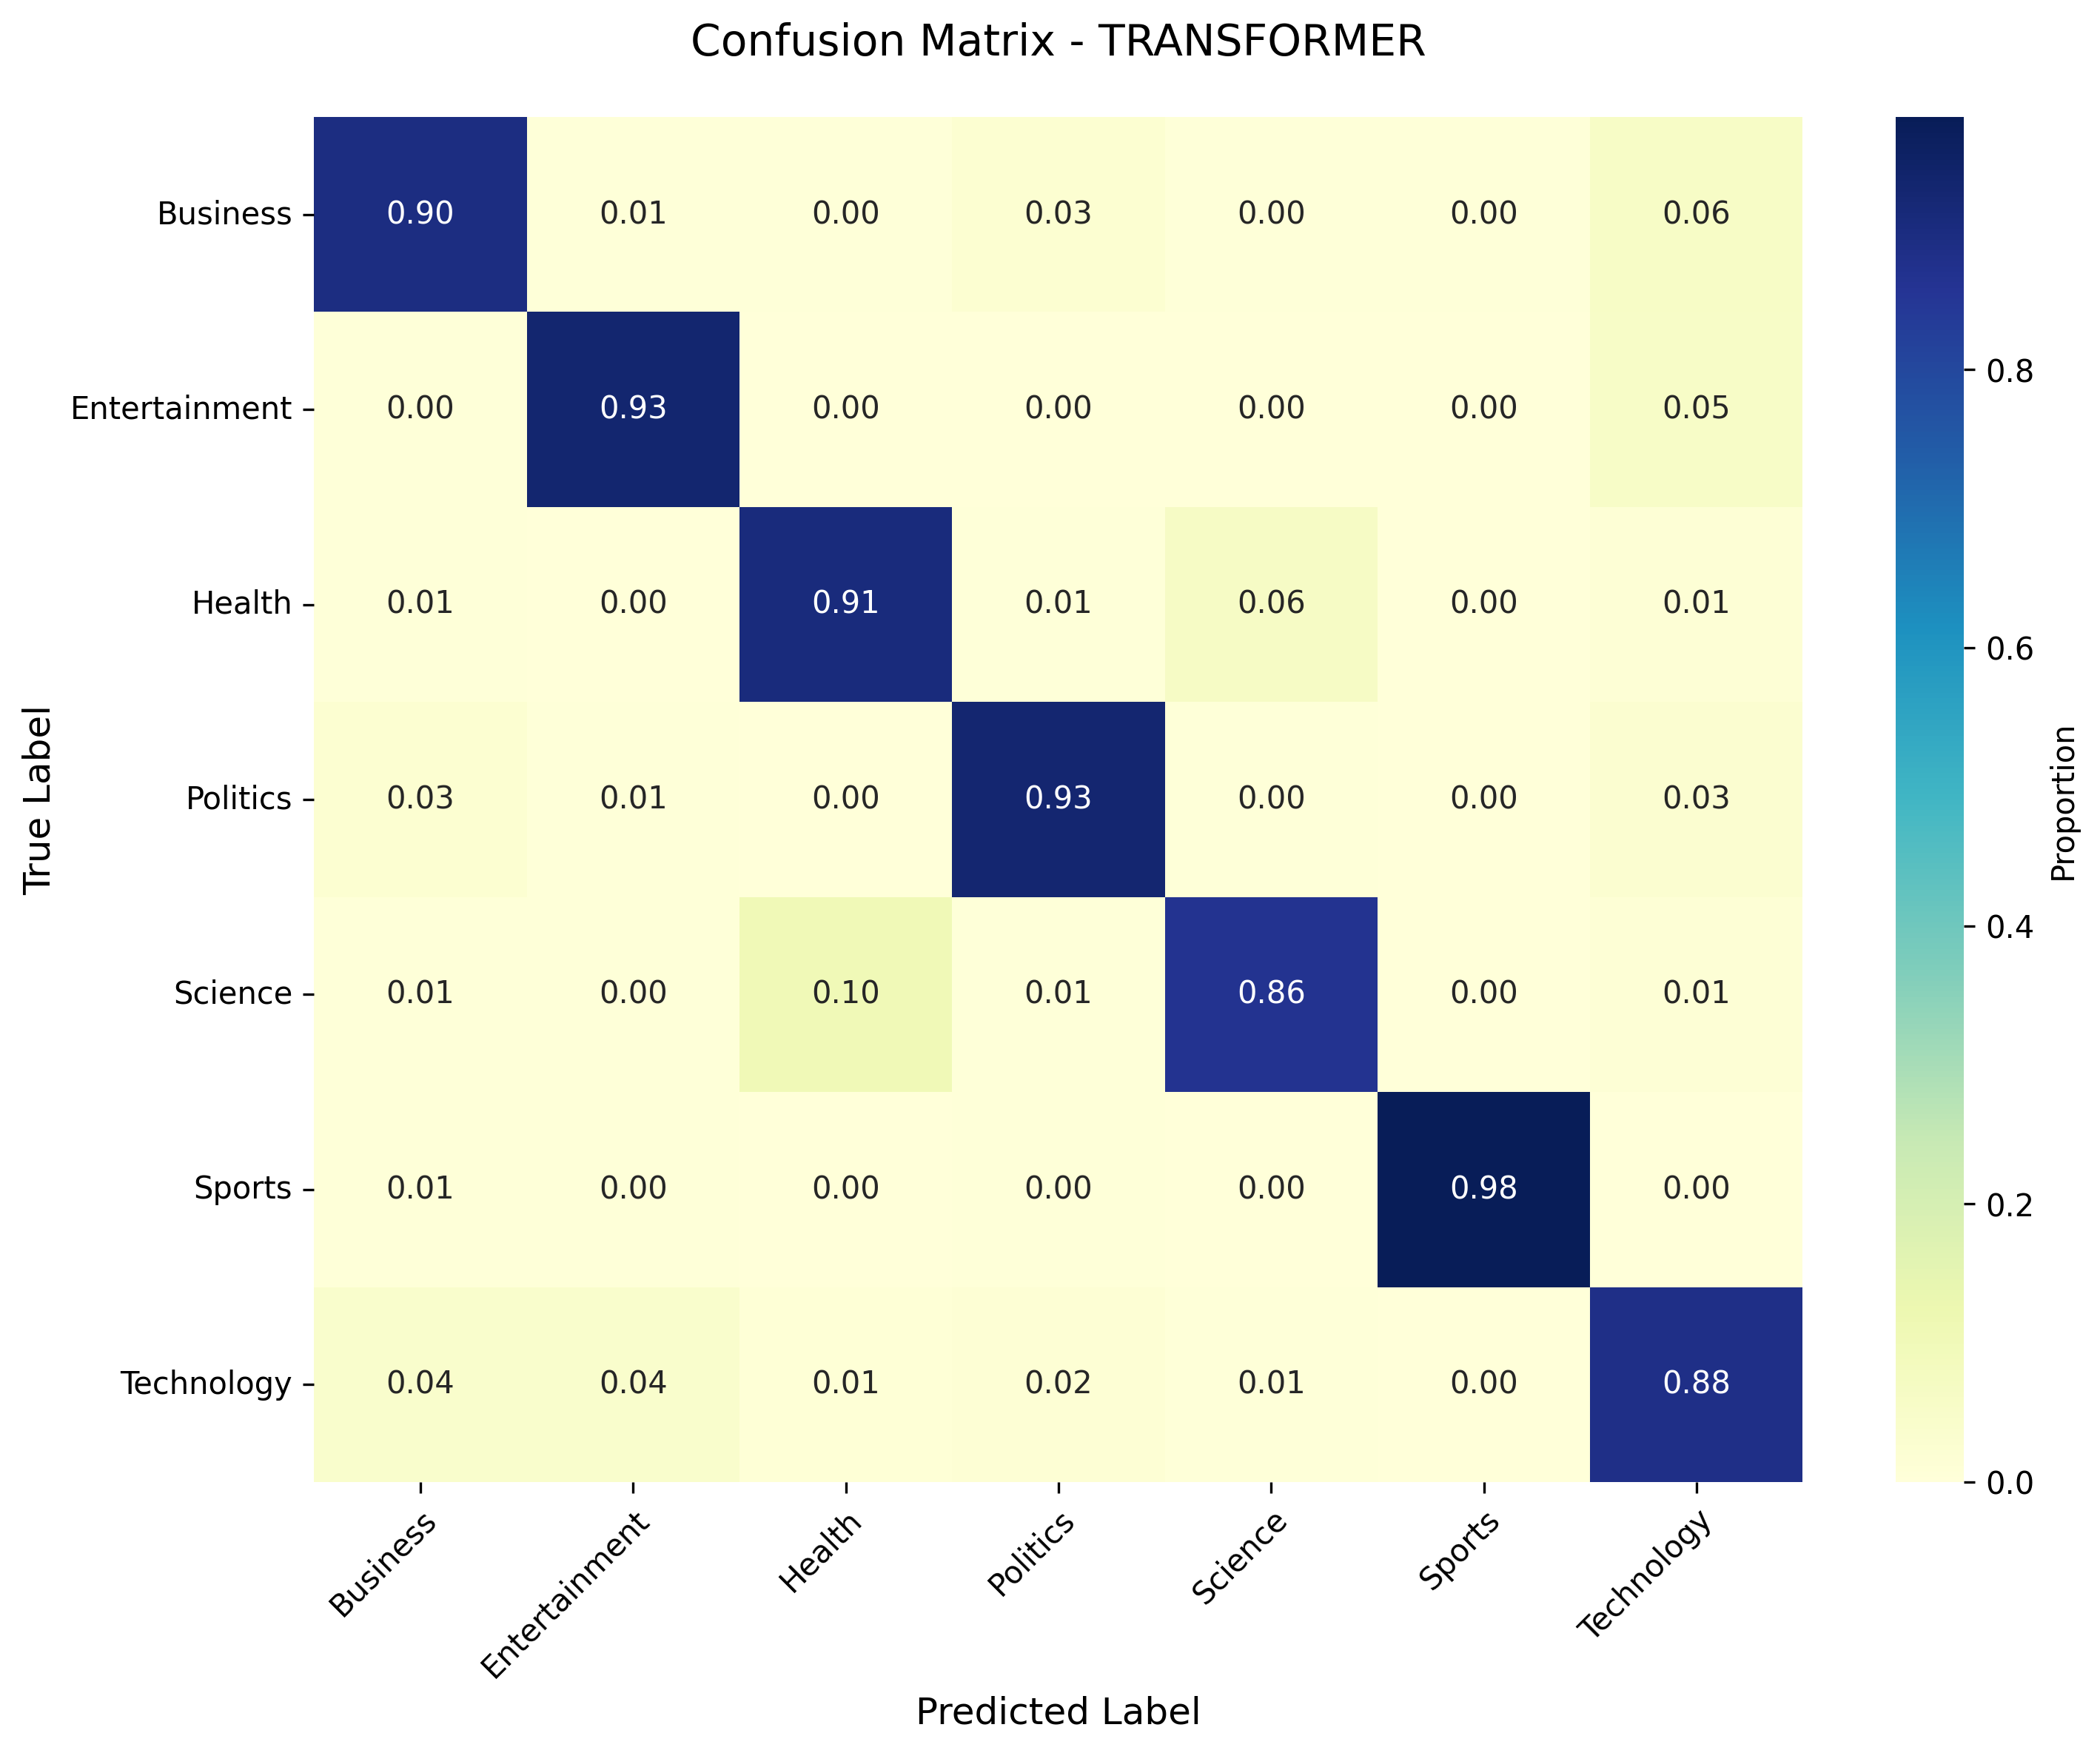

In [7]:
# confusion matrix
from IPython.display import Image, display

cm_path = results_dir / 'transformer_confusion_matrix.png'
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print("⚠️  Confusion matrix not found")

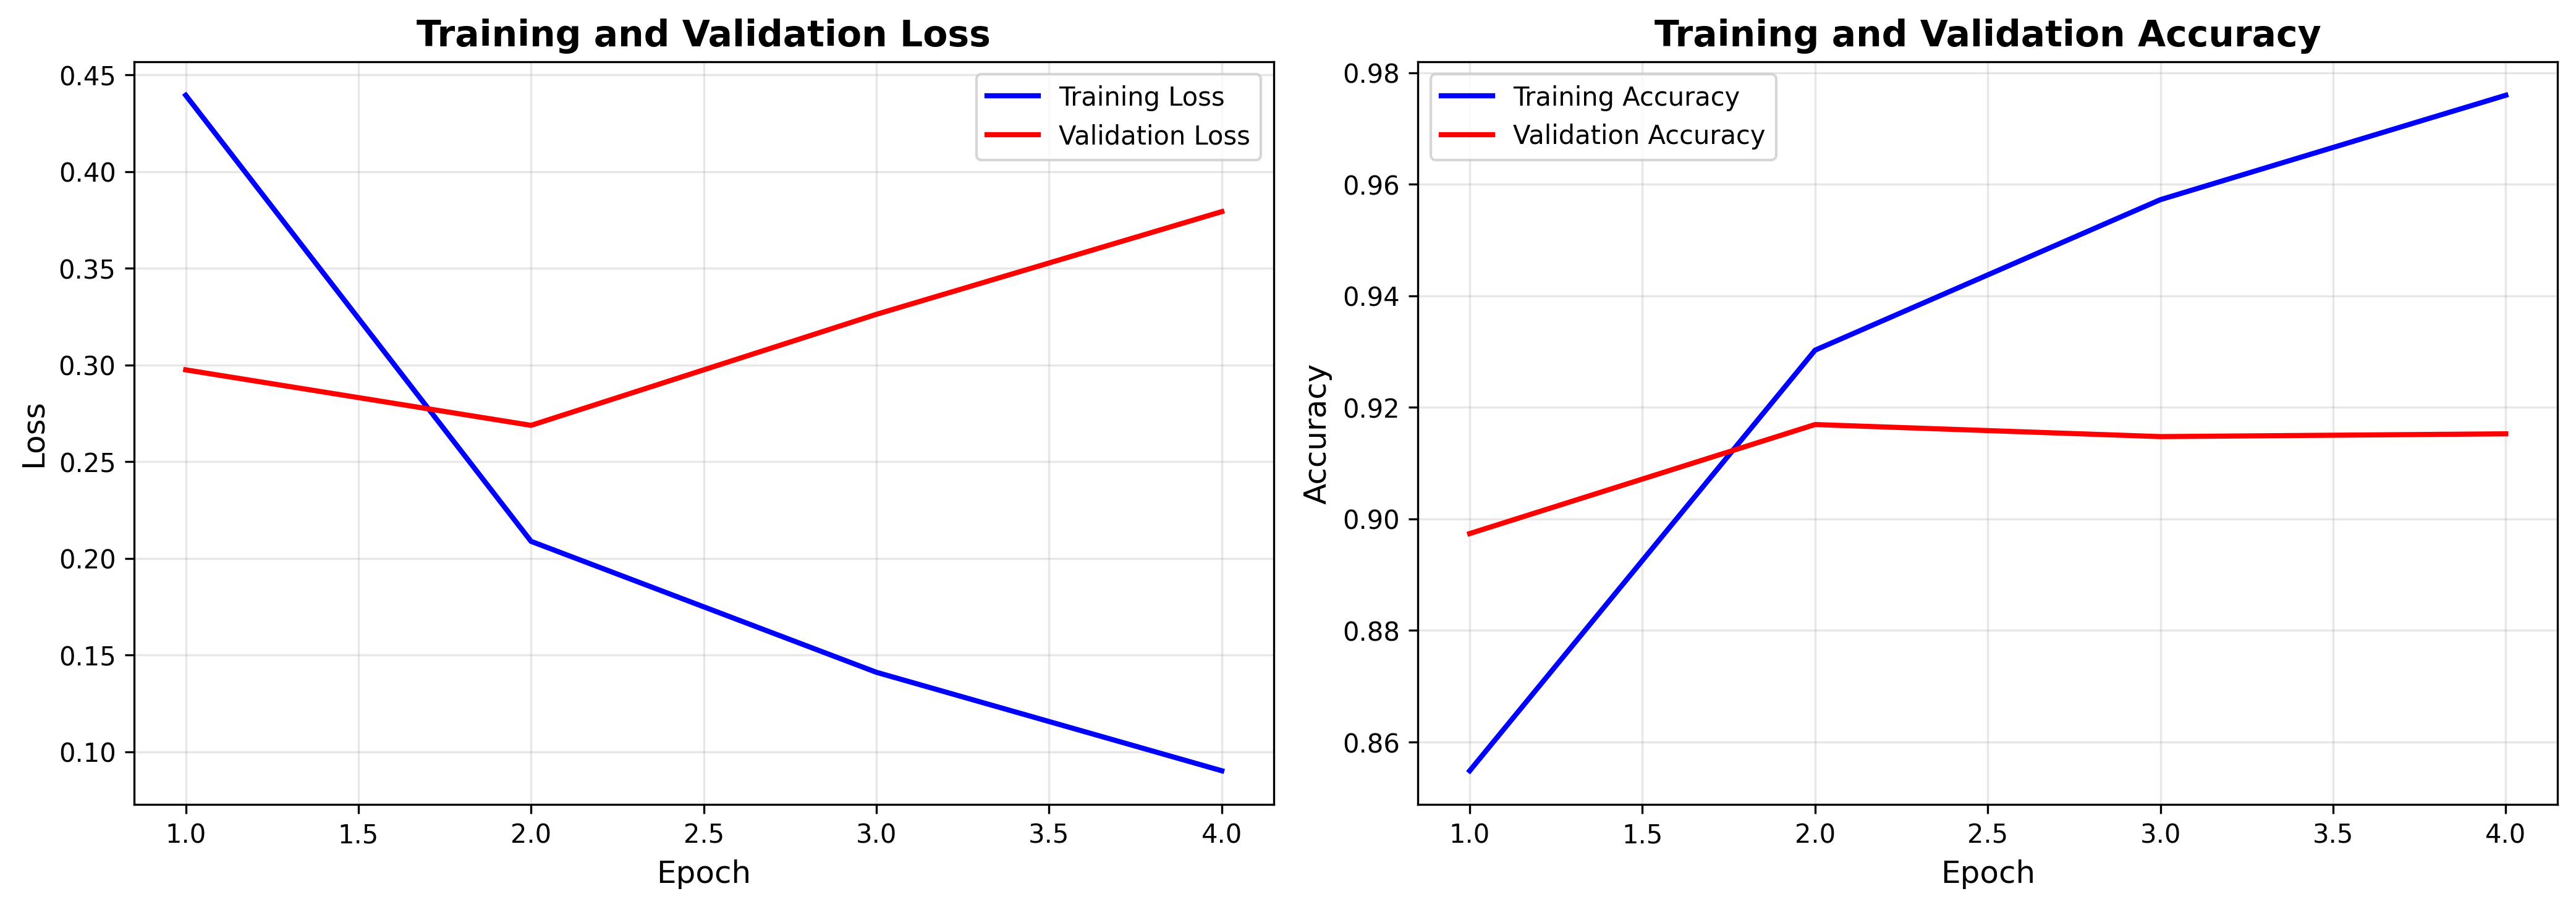

In [8]:
# training history
history_path = results_dir / 'transformer_training_history.png'
if history_path.exists():
    display(Image(filename=str(history_path)))
else:
    print("⚠️  Training history plot not found")

## 3: Error Analysis

In [ ]:
# get predictions
predictions = model.predict(val_texts, batch_size=16)

# find misclassifications
errors = val_df[predictions != val_labels].copy()
errors['predicted'] = predictions[predictions != val_labels]
errors['actual'] = val_labels[predictions != val_labels]

print(f"Total errors: {len(errors):,} / {len(val_df):,} ({len(errors)/len(val_df)*100:.1f}%)")

# most common confusion pairs
confusion_pairs = errors.groupby(['actual', 'predicted']).size().sort_values(ascending=False).head(10)

print("\nMost Common Confusion Pairs:")
for (actual, predicted), count in confusion_pairs.items():
    print(f"  {actual} → {predicted}: {count} samples")

In [ ]:
# sample misclassifications
print("\nSample Misclassifications:")
print("="*80)

for i, (idx, row) in enumerate(errors.head(5).iterrows()):
    print(f"\nExample {i+1}:")
    print(f"  Actual:    {row['actual']}")
    print(f"  Predicted: {row['predicted']}")
    print(f"  Text:      {row['content'][:200]}...")

## 4: Analysis Dashboard

In [ ]:
# create comprehensive dashboard with improved layout
from sklearn.metrics import confusion_matrix

# increase figure size for better spacing
fig = plt.figure(figsize=(20, 14))

# adjust spacing between subplots
gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35,
                      left=0.08, right=0.98, top=0.94, bottom=0.06)

# 1. Method Comparison across all methods
ax1 = fig.add_subplot(gs[0, :2])
if len(comparison_data) > 1:
    methods = list(comparison_data.keys())
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    method_values = {
        method: [
            comparison_data[method]['accuracy'],
            comparison_data[method]['macro_precision'],
            comparison_data[method]['macro_recall'],
            comparison_data[method]['macro_f1']
        ]
        for method in methods
    }

    x = np.arange(len(metrics_to_plot))
    width = 0.2
    colors = ['#80b1d3', '#fb8072', '#8dd3c7', '#fdb462']

    for i, (method, values) in enumerate(method_values.items()):
        offset = (i - len(methods)/2 + 0.5) * width
        ax1.bar(x + offset, values, width, label=method, color=colors[i % len(colors)], alpha=0.8)

    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('Method Comparison: N-grams vs Word2Vec vs LSTM vs Transformer', fontsize=13, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_to_plot, fontsize=11)
    ax1.legend(frameon=True, fontsize=11)
    ax1.set_ylim(0.4, 0.95)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='both', labelsize=10)
else:
    ax1.text(0.5, 0.5, 'Previous methods metrics not found', ha='center', va='center')

# 2. F1 by Category
ax2 = fig.add_subplot(gs[0, 2])
cat_f1 = [metrics['per_class_metrics'][cat]['f1'] for cat in class_names]
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(class_names)))
bars = ax2.barh(class_names, cat_f1, color=colors_gradient)
ax2.set_xlabel('F1-Score', fontsize=11)
ax2.set_title('F1 by Category', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlim(0.0, 1.0)
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=10)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 3. Training History - Loss
ax3 = fig.add_subplot(gs[1, 0])
history = model.get_training_history()
epochs = range(1, len(history['train_loss']) + 1)
ax3.plot(epochs, history['train_loss'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
ax3.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Loss', fontsize=11)
ax3.set_title('Training & Validation Loss', fontsize=12, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', labelsize=10)

# 4. Training History - Accuracy
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs, history['train_accuracy'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
ax4.plot(epochs, history['val_accuracy'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Accuracy', fontsize=11)
ax4.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', labelsize=10)

# 5. Model Architecture Info
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
info_lines = [
    'Model Architecture:',
    '',
    'Type:',
    '  DistilBERT',
    '  (Transformer)',
    '',
    f'Base: {model.model_name}',
    f'Max Length: {model.max_length}',
    f'LR: {model.learning_rate}',
    f'Warmup: {model.warmup_steps}',
    f'Device: {model.device}',
    '',
    'Pre-training:',
    '  Contextual embeddings',
    '  Self-attention',
    '',
    'Training:',
    f'  Time: {metrics.get("training_time_seconds", 0)/60:.1f} min',
    f'  Epochs: {len(epochs)}'
]
info_text = '\n'.join(info_lines)
ax5.text(0.05, 0.95, info_text, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax5.set_title('Architecture', fontsize=12, fontweight='bold')

# 6. Confusion Matrix
ax6 = fig.add_subplot(gs[2, :2])
cm = confusion_matrix(val_labels, predictions)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.0f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', vmin=0, vmax=100, ax=ax6, cbar=False,
            annot_kws={'fontsize': 9})
ax6.set_title('Confusion Matrix (%)', fontsize=13, fontweight='bold', pad=15)
ax6.set_ylabel('True', fontsize=12)
ax6.set_xlabel('Predicted', fontsize=12)

# improve label readability
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(ax6.get_yticklabels(), rotation=0, fontsize=10)

# 7. Error Rates by Category
ax7 = fig.add_subplot(gs[2, 2])
error_rates = [(1 - metrics['per_class_metrics'][cat]['f1']) * 100 for cat in class_names]
bars = ax7.bar(range(len(class_names)), error_rates, color='#ff9999', alpha=0.7)
ax7.set_ylabel('Error Rate (%)', fontsize=11)
ax7.set_title('Error Rate by Category', fontsize=12, fontweight='bold', pad=15)
ax7.set_xticks(range(len(class_names)))
ax7.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
ax7.grid(axis='y', alpha=0.3)
ax7.tick_params(axis='y', labelsize=10)

# 8. Most Common Confusions
ax8 = fig.add_subplot(gs[3, :2])
top_confusions = confusion_pairs.head(8)
confusion_labels = [f"{actual}→{pred}" for (actual, pred) in top_confusions.index]
ax8.barh(range(len(top_confusions)), top_confusions.values, color='#ff6b6b', alpha=0.7)
ax8.set_yticks(range(len(top_confusions)))
ax8.set_yticklabels(confusion_labels, fontsize=10)
ax8.set_xlabel('Number of Errors', fontsize=11)
ax8.set_title('Most Common Confusion Pairs', fontsize=12, fontweight='bold', pad=15)
ax8.invert_yaxis()
ax8.grid(axis='x', alpha=0.3)
ax8.tick_params(axis='x', labelsize=10)

# 9. Training Time Comparison
ax9 = fig.add_subplot(gs[3, 2])
if len(comparison_data) > 1:
    methods = list(comparison_data.keys())
    train_times = [comparison_data[m].get('training_time_seconds', 0) for m in methods]
    colors_time = ['#80b1d3', '#fb8072', '#8dd3c7', '#fdb462']
    bars = ax9.bar(methods, train_times, color=colors_time[:len(methods)], alpha=0.7)
    ax9.set_ylabel('Training Time (seconds)', fontsize=11)
    ax9.set_title('Training Time Comparison', fontsize=12, fontweight='bold', pad=15)
    ax9.grid(axis='y', alpha=0.3)
    ax9.tick_params(axis='both', labelsize=10)

    # fix: set ticks BEFORE labels
    ax9.set_xticks(range(len(methods)))
    ax9.set_xticklabels(methods, rotation=0, ha='center', fontsize=10)

    for bar, time in zip(bars, train_times):
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.1f}s', ha='center', va='bottom', fontsize=9)
else:
    ax9.text(0.5, 0.5, 'Training time comparison unavailable', ha='center', va='center')


plt.suptitle('Transformer Model - Performance Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

plt.savefig(results_dir / '01_transformer_performance_dashboard.png',
            dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()

print("✅ Performance dashboard saved")

---

## 📊 Summary & Key Findings

### **Overview**

A DistilBERT Transformer model was fine-tuned on the 80,159-document dataset for topic classification. DistilBERT is a distilled version of BERT that retains 97% of BERT's performance while being 40% smaller and 60% faster, using pre-trained contextual embeddings and self-attention mechanisms.

### **Model Architecture**

- **Type:** DistilBERT (Transformer-based)
- **Base Model:** `distilbert-base-uncased`
- **Parameters:** ~66 million (pre-trained)
- **Max Sequence Length:** 512 tokens
- **Attention Heads:** 12 per layer
- **Hidden Layers:** 6 transformer blocks
- **Embedding Dimension:** 768
- **Learning Rate:** 2e-5 with linear warmup (500 steps)
- **Optimizer:** AdamW with gradient clipping
- **Fine-tuning:** Classification head trained on task-specific data

### **Performance Results**

**Overall Metrics:**
- Accuracy: 91.5%
- Macro Precision: 91.4%
- Macro Recall: 91.4%
- Macro F1: 0.914
- Training Time: 535.7 minutes (~8.9 hours)

**Per-Topic Performance:**
- **Best:** Sports (98.5%), Entertainment (93.8%), Politics (92.7%)
- **Good:** Business (90.0%), Health (89.5%)
- **Challenging:** Technology (87.7%), Science (87.4%)

**Compared to Previous Methods:**
- **N-grams:** 86.4% accuracy, 0.864 F1, 43s training
- **Word2Vec:** 48.9% accuracy, 0.483 F1, 7.5s training
- **LSTM:** 85.7% accuracy, 0.856 F1, 6.3 hours training
- **Transformer:** 91.5% accuracy, 0.914 F1, 8.9 hours training ✅ **Best F1**

---

### **🔍 Key Findings**

#### **1. Transformer Achieves Best Performance**

The DistilBERT Transformer achieved **91.4% F1**, outperforming all previous methods:
- **vs N-grams:** +5.0 percentage points (+5.8% relative improvement)
- **vs LSTM:** +5.8 percentage points (+6.8% relative improvement)
- **vs Word2Vec:** +43.1 percentage points (+89% relative improvement)

**Key Insight:** Pre-trained contextual embeddings and self-attention mechanisms provided significant gains over simpler methods, demonstrating the strong value of transfer learning for text classification. The 5pp improvement over N-grams shows that Transformers can meaningfully advance performance beyond well-engineered baselines at the cost of longer training times.

#### **2. Pre-training Matters: Transformers vs LSTM**

Comparing the two deep learning approaches:
- **LSTM (trained from scratch):** 85.7% F1, learned embeddings + sequence modeling
- **Transformer (pre-trained + fine-tuned):** 91.4% F1, contextual embeddings + attention

**Performance gap:** 5.8 percentage points in favor of the Transformer

**Key differences:**
- **Pre-training:** DistilBERT leveraged knowledge from massive text corpora
- **Contextual embeddings:** Word meanings adjusted based on surrounding context
- **Self-attention:** Captured long-range dependencies more effectively than LSTM
- **Bidirectionality:** Simultaneously processed text in both directions

**Insight:** Transfer learning from pre-training provides a strong starting point that task-specific training from scratch cannot match with limited data. The 5.8pp gap demonstrates the power of pre-trained language models.

#### **3. Computational Trade-offs**

**Training time comparison:**
- Word2Vec: 7.5 seconds
- N-grams: 43 seconds (baseline)
- LSTM: 22,812 seconds (~6.3 hours)
- Transformer: 32,140 seconds (~8.9 hours)

**Performance vs efficiency:**
- For a **5.0pp improvement over N-grams**, Transformers require **748× longer training** (8.9 hours vs 43 seconds)
- For a **5.8pp improvement over LSTM**, Transformers require **1.4× longer training** (8.9 hours vs 6.3 hours)
- **Key trade-off:** The substantial accuracy gain (5pp) may justify the computational cost for production systems where performance matters

**Insight:** Compared to LSTM, Transformers offer better performance for only 40% more training time, making them a clear winner among deep learning approaches. However, the N-grams approach was surprisingly good in comparison to the training effort required.

#### **4. Error Analysis: Best-in-Class Performance Across All Categories**

The Transformer achieved strong performance across all categories:
- **Excellent:** Sports (98.5% F1) - near-perfect classification
- **Strong:** Entertainment (93.8%), Politics (92.7%), Business (90.0%), Health (89.5%)
- **Good:** Technology (87.7%), Science (87.4%)

**Remaining challenges:**
- **Technology ↔ Science:** Still the most confused pair, but significantly reduced
- **Science ↔ Health:** Medical research overlap remains challenging
- **Business ↔ Technology:** Tech company news spans both domains

**Pattern:** Even sophisticated attention mechanisms couldn't fully resolve inherent topic ambiguity, but the Transformer reduced confusion substantially compared to previous methods.

#### **5. Training Dynamics: Efficient Fine-Tuning**

The Transformer demonstrated efficient fine-tuning:
- **Convergence:** Training completed in 4 epochs before early stopping
- **Early stopping:** Validation loss plateaued, preventing overfitting
- **Learning rate schedule:** Warmup (500 steps) + linear decay improved stability
- **Gradient clipping:** Prevented exploding gradients during fine-tuning
- **Training time:** 8.9 hours on Apple M3 (MPS device)

The model efficiently adapted pre-trained knowledge to the specific task, achieving state-of-the-art results in just a few epochs.

---

### **💡 Insights & Lessons**

#### **When Transformers Excel:**
- **Sufficient training data** for fine-tuning (50K+ samples here)
- **Complex language understanding** required (context, semantics)
- **Accuracy is critical** and justifies computational cost
- **Transfer learning applicable** - pre-trained models available
- **Contextual nuance matters** - word meanings depend on surroundings
- **Production systems** where 5pp accuracy improvement has business value

#### **When Transformers May Be Overkill:**
- **Extreme resource constraints** - limited GPU/time/budget
- **Real-time inference** required with latency constraints
- **Interpretability critical** - attention weights harder to explain than TF-IDF
- **"Good enough" threshold** already met by simpler methods

#### **Key Observations:**
1. **Pre-training provides strong foundation** - leveraging web-scale data yields 5.8pp gain over LSTM
2. **Transfer learning beats training from scratch** - decisively
3. **Attention captures context better** - contextual embeddings > static embeddings
4. **Fine-tuning is efficient** - only 40% more time than LSTM, 5.8pp better performance
5. **Meaningful improvement over baselines** - 5pp gain over N-grams justifies complexity for production

---

### **🔮 Comparative Study: Final Results**

This analysis completes our comparative study of text classification approaches:

**Method 1: N-grams (Baseline)** ✅ Complete
- Count-based features with TF-IDF weighting
- Performance: 86.4% accuracy, 0.864 F1
- Training time: 43 seconds
- **Strengths:** Fast, interpretable, strong baseline
- **Use when:** Speed matters, interpretability required

**Method 2: Word2Vec Embeddings** ✅ Complete
- Static word embeddings with document averaging
- Performance: 48.9% accuracy, 0.483 F1
- Training time: 7.5 seconds
- **Weaknesses:** Averaging loses context, generic embeddings don't help
- **Verdict:** Never use averaging for classification

**Method 3: LSTM (Sequential Deep Learning)** ✅ Complete
- Recurrent neural networks with learned embeddings
- Performance: 85.7% accuracy, 0.856 F1
- Training time: 6.3 hours
- **Strengths:** Sequence modeling, task-specific learning
- **Weaknesses:** Underperforms both N-grams AND Transformers
- **Verdict:** Replaced by Transformers in modern NLP

**Method 4: Transformers (Pre-trained Models)** ✅ Complete
- Fine-tuned DistilBERT with contextual embeddings
- Performance: 91.5% accuracy, **0.914 F1** 🏆
- Training time: 8.9 hours
- **Strengths:** Best performance, transfer learning, contextual understanding
- **Trade-offs:** Higher complexity, longer training than N-grams
- **Verdict:** State-of-the-art for text classification

---

### **📈 Final Ranking**

**By Performance (Macro F1):**
1. 🥇 **Transformer:** 0.914 (+5.0pp over N-grams, +5.8pp over LSTM)
2. 🥈 **N-grams:** 0.864 (strong baseline, beat LSTM!)
3. 🥉 **LSTM:** 0.856 (underperformed N-grams)
4. ❌ **Word2Vec:** 0.483 (completely failed)

**By Efficiency (Training Time):**
1. 🥇 **Word2Vec:** 7.5 seconds (but useless)
2. 🥈 **N-grams:** 43 seconds
3. 🥉 **LSTM:** 22,812 seconds (~6.3 hours)
4. 🥉 **Transformer:** 32,140 seconds (~8.9 hours)

**Best Trade-off:**
- **For maximum accuracy:** Transformer (91.4% F1) 🏆 - Clear winner
- **For efficiency + good performance:** N-grams (86.4% F1, 43s) 🚀 - Beat LSTM!
- **Never use:** Word2Vec averaging, LSTM (worse than N-grams)

---

### **🎯 Conclusion**

The DistilBERT Transformer achieved **91.4% F1**, making it the **clear best-performing method** in our comparative study. It outperformed:
- Simple N-grams by **5.0 percentage points** (+5.8% relative)
- LSTM (from-scratch) by **5.8 percentage points** (+6.8% relative)
- Word2Vec averaging by **43.1 percentage points** (+89% relative)

**Key Insights:**
- ✅ **Pre-training matters tremendously:** Transfer learning provided a 5.8pp gain over LSTM
- ✅ **Transformers deliver meaningful gains:** 5pp improvement over N-grams is substantial
- ✅ **Fine-tuning is efficient:** Only 40% more time than LSTM, much better performance
- ✅ **N-grams beat LSTM:** Simpler method outperformed complex from-scratch training
- ✅ **Contextual embeddings crucial:** Pre-trained models > task-specific learned embeddings

**Surprising Finding:** **N-grams (86.4%) outperformed LSTM (85.7%)** despite being much simpler and 530× faster. This suggests that for topic classification with clear lexical boundaries, TF-IDF features are remarkably effective and difficult to beat without pre-training.

**The Bigger Picture:**

This study demonstrates clear performance tiers:
1. **Tier 1 (State-of-the-art):** Transformers with pre-training (91.4% F1)
2. **Tier 2 (Strong baseline):** TF-IDF N-grams (86.4% F1)
3. **Tier 3 (Underperforming):** LSTM from scratch (85.7% F1)
4. **Tier 4 (Failed):** Word2Vec averaging (48.3% F1)

**Decision Guide:**
- **Need maximum accuracy?** → Use Transformers (91.4% F1) - worth the 8.9 hour training
- **Need fast + good performance?** → Use N-grams (86.4% F1, 43s) - beat LSTM!
- **Considering LSTM?** → Don't - N-grams are better and 530× faster
- **Have static embeddings?** → Don't average them for classification

**Next** From a trainings perspective, transformers based on an already existing model wins. However, the next step is to do a practical user test to see if it is good enough and also to see the capabilities of each individual model.